In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

plt.style.use('default')
sns.set_theme()

In [11]:
train_data = pd.read_csv('archive/train.csv')
val_data = pd.read_csv('archive/validation.csv')
test_data = pd.read_csv('archive/test.csv')



In [12]:
features = ['AttendanceRate', 'StudyHours']
target = 'GPA'

In [15]:
# Prepare data
train_x = train_data[features]
val_x = val_data[features]
test_x = test_data[features]

train_y = train_data[target]
val_y = val_data[target]
test_y = test_data[target]


In [16]:
# Scale features
scaler = StandardScaler()
train_x_scaled = scaler.fit_transform(train_x)
val_x_scaled = scaler.transform(val_x)
test_x_scaled = scaler.transform(test_x)

In [17]:
# Initialize and train model
model = Ridge(random_state=42)

# Hyperparameter tuning
param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100],
    'fit_intercept': [True, False]
}

grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(train_x_scaled, train_y)

# Get best model
best_model = grid_search.best_estimator_

# Make predictions
pred_train_y = best_model.predict(train_x_scaled)
pred_val_y = best_model.predict(val_x_scaled)
pred_test_y = best_model.predict(test_x_scaled)

print("Best parameters:", grid_search.best_params_)

Best parameters: {'alpha': 1, 'fit_intercept': True}


In [18]:
def evaluate_model(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\nPerformance on {dataset_name} dataset:")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R² Score: {r2:.4f}")

# Evaluate on all datasets
evaluate_model(train_y, pred_train_y, "Training")
evaluate_model(val_y, pred_val_y, "Validation")
evaluate_model(test_y, pred_test_y, "Test")


Performance on Training dataset:
MSE: 0.1075
RMSE: 0.3278
R² Score: 0.4910

Performance on Validation dataset:
MSE: 0.1076
RMSE: 0.3280
R² Score: 0.4915

Performance on Test dataset:
MSE: 0.1075
RMSE: 0.3278
R² Score: 0.4910


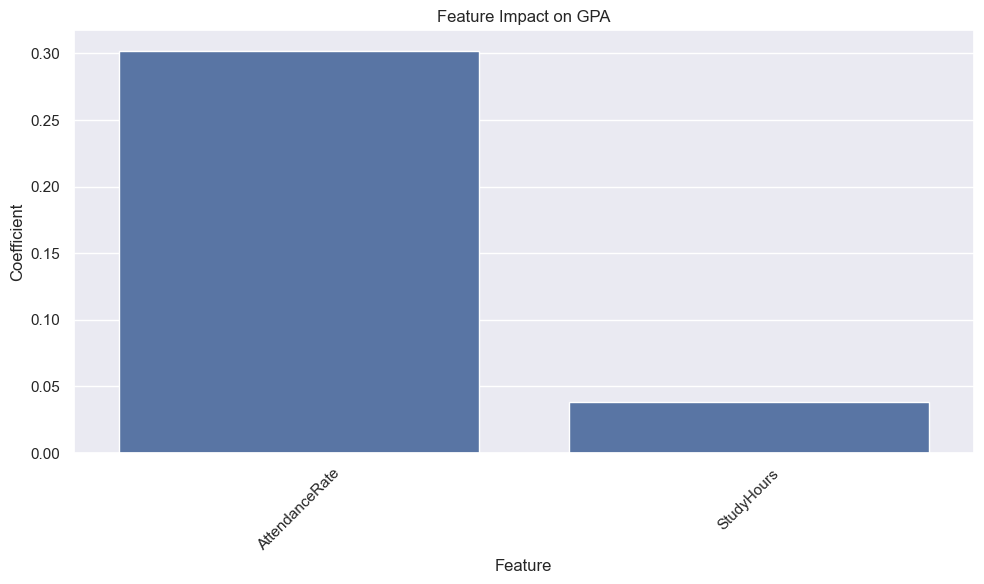

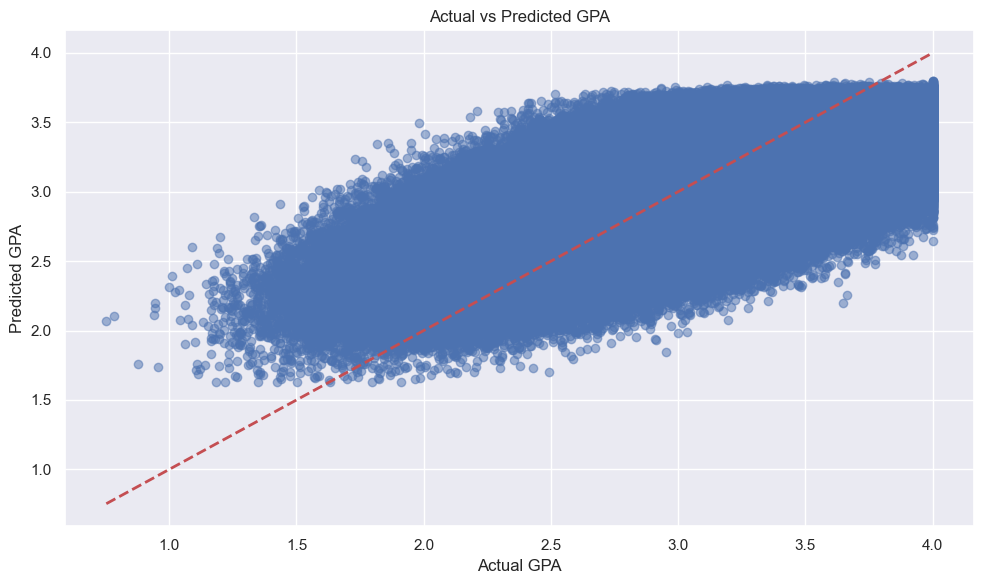

In [19]:
# Plot coefficients
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': best_model.coef_
})
coefficients['Absolute_Coefficient'] = abs(coefficients['Coefficient'])
coefficients = coefficients.sort_values('Absolute_Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Feature', y='Coefficient', data=coefficients)
plt.title('Feature Impact on GPA')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot actual vs predicted
plt.figure(figsize=(10, 6))
plt.scatter(test_y, pred_test_y, alpha=0.5)
plt.plot([test_y.min(), test_y.max()], [test_y.min(), test_y.max()], 'r--', lw=2)
plt.xlabel('Actual GPA')
plt.ylabel('Predicted GPA')
plt.title('Actual vs Predicted GPA')
plt.tight_layout()
plt.show()

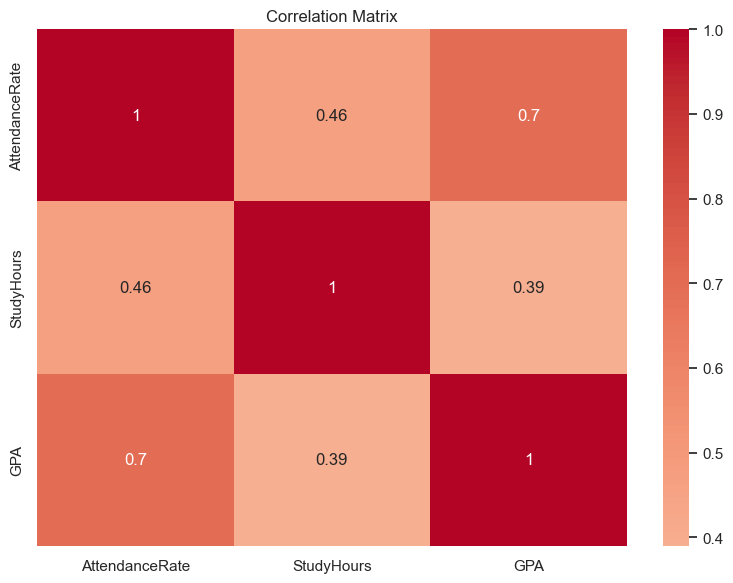


Correlation with GPA:
GPA               1.000000
AttendanceRate    0.696722
StudyHours        0.389857
Name: GPA, dtype: float64


In [20]:
# Calculate correlation matrix
correlation_matrix = train_data[features + [target]].corr()

# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

# Print correlation with target
print("\nCorrelation with GPA:")
print(correlation_matrix[target].sort_values(ascending=False))

In [21]:
# Save results
results = {
    'model_params': {
        'alpha': best_model.alpha,
        'fit_intercept': best_model.fit_intercept,
        'intercept': best_model.intercept_,
        'coefficients': dict(zip(features, best_model.coef_))
    },
    'performance': {
        'train': {
            'mse': mean_squared_error(train_y, pred_train_y),
            'rmse': np.sqrt(mean_squared_error(train_y, pred_train_y)),
            'r2': r2_score(train_y, pred_train_y)
        },
        'validation': {
            'mse': mean_squared_error(val_y, pred_val_y),
            'rmse': np.sqrt(mean_squared_error(val_y, pred_val_y)),
            'r2': r2_score(val_y, pred_val_y)
        },
        'test': {
            'mse': mean_squared_error(test_y, pred_test_y),
            'rmse': np.sqrt(mean_squared_error(test_y, pred_test_y)),
            'r2': r2_score(test_y, pred_test_y)
        }
    },
    'feature_importance': coefficients.to_dict('records')
}

# Save feature importance to CSV
coefficients.to_csv('feature_importance_gpa.csv', index=False)

# Print final summary
print("\n=== Final Analysis Results ===")
print("\nModel Coefficients:")
print(coefficients)
print("\nModel Intercept:", best_model.intercept_)


=== Final Analysis Results ===

Model Coefficients:
          Feature  Coefficient  Absolute_Coefficient
0  AttendanceRate     0.302190              0.302190
1      StudyHours     0.038631              0.038631

Model Intercept: 2.996742902272259
